# 4. Performance Tracking

## Overview
This notebook implements performance tracking for our ETF portfolio across all four asset classes, including:
1. Historical price data collection via yfinance
2. Return calculations (UK financial year Apr-Mar, YTD, MTD)
3. Risk metrics (volatility, Sharpe ratio)
4. Rebalancing-aware time-weighted return (TWR) from trading statements
5. Portfolio-level P&L and performance reporting

Portfolio data is loaded from the SQLite database (year = 2025), falling back to CSV.

## Required Libraries

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path("..").resolve()))

from datetime import datetime, timedelta

import pandas as pd
import numpy as np

from etf_utils.config import DATA_RAW, DATA_INTERMEDIATE, DATA_OUTPUT, DATA_CONFIG
from etf_utils.data_provider import DataProvider
from etf_utils.database import load_portfolio
from etf_utils.metrics import (
    calculate_annualized_volatility,
    calculate_period_metrics,
    calculate_daily_pnl,
)

provider = DataProvider()

# Load portfolio from DB (year=2025)
portfolio_df = load_portfolio(year=2025)
print(f"Loaded {len(portfolio_df)} positions from 2025 portfolio "
      f"(asset classes: {portfolio_df['asset_class'].unique().tolist()})")

Loaded 16 positions from 2025 portfolio (asset classes: ['equity', 'bonds'])


## 1. Rebalancing-Aware Portfolio Performance (Time-Weighted Return)

This section parses the InvestEngine trading statement to calculate a highly accurate
time-weighted return that explicitly accounts for actual rebalancing cash-flows over time.

### 1.1 Data Loading & Price Fetching

In [2]:
"""
Rebalancing-Aware Portfolio Performance — Data Loading
======================================================
Loads trades from CSV (or DB fallback) and fetches price data.
"""

import re
import importlib
from collections import defaultdict
import pandas as pd
import numpy as np
from pathlib import Path

# Reload data_provider to pick up the latest fixes
import etf_utils.data_provider
importlib.reload(etf_utils.data_provider)
from etf_utils.data_provider import DataProvider
from etf_utils.database import save_rebalancing_trades, load_rebalancing_trades
provider = DataProvider()

# ---------- 1. ISIN → Ticker mapping ----------
ISIN_TO_TICKER = {
    "IE00BZ163G84": "VECP",   # Vanguard EUR Corporate Bond
    "IE00B1XNH568": "IMIB",   # iShares FTSE MIB
    "IE00B0M63516": "IBZL",   # iShares MSCI Brazil
    "LU1048314949": "UC81",   # UBS US Liquid Corp Bonds
    "LU1931975152": "PRIR",   # Amundi Euro Govt Bonds
    "IE00B6TLBW47": "EMCP",   # iShares EM Corp Bond
    "IE00B00FV011": "SLXX",   # iShares Corporate Bond
    "IE00BD4TY345": "AUAD",   # UBS MSCI Australia
    "IE00B1FZSB30": "IGLT",   # iShares Core UK Gilts
    "IE00BF2FN646": "TRXG",   # Invesco US Treasury 7-10Y
    "IE00B44T3H88": "HMCH",   # HSBC MSCI China
    "LU0838782315": "XDDX",   # Xtrackers DAX
    "IE00BZ163L38": "VEMT",   # Vanguard EM Govt Bonds
    "LU1931974775": "PRIJ",   # Amundi Prime Japan
    "IE00BM8R0J59": "QYLP",   # Global X Nasdaq 100 CC
    "LU1781541096": "LCUK",   # Amundi Core UK Equity
}

from etf_utils.config import PROJECT_ROOT

# ---------- 2. Load trades: CSV (parse + save to DB) or DB fallback ----------
PORTFOLIO_YEAR = 2025

statement_path = (
    PROJECT_ROOT
    / "data"
    / "investment_statements"
    / f"RebalancingTrades{PORTFOLIO_YEAR}.csv"
)

if statement_path.exists():
    trades_raw = pd.read_csv(statement_path, skiprows=2, header=None,
                             names=["security", "type", "quantity", "price", "value",
                                    "trade_datetime", "settlement_date", "broker"])

    trades_raw["isin"] = trades_raw["security"].str.extract(r"ISIN\s+([A-Z]{2}[A-Z0-9]{10})")
    trades_raw["ticker"] = trades_raw["isin"].map(ISIN_TO_TICKER)

    trades_raw["trade_date"] = pd.to_datetime(
        trades_raw["trade_datetime"].str.strip(), format="%d/%m/%y %H:%M:%S"
    ).dt.normalize()

    trades_raw["quantity"] = pd.to_numeric(trades_raw["quantity"], errors="coerce")
    trades_raw["price"] = (
        trades_raw["price"].astype(str).str.replace("\u00a3", "", regex=False).str.replace(",", "")
    )
    trades_raw["price"] = pd.to_numeric(trades_raw["price"], errors="coerce")
    trades_raw["value"] = (
        trades_raw["value"].astype(str).str.replace("\u00a3", "", regex=False).str.replace(",", "")
    )
    trades_raw["value"] = pd.to_numeric(trades_raw["value"], errors="coerce")

    trades = trades_raw.dropna(subset=["ticker", "trade_date"]).copy()

    trades["signed_qty"] = trades.apply(
        lambda r: r["quantity"] if r["type"].strip() == "Buy" else -r["quantity"], axis=1
    )
    trades["signed_value"] = trades.apply(
        lambda r: r["value"] if r["type"].strip() == "Buy" else -r["value"], axis=1
    )

    save_rebalancing_trades(trades, portfolio_year=PORTFOLIO_YEAR)
    print(f"Parsed CSV and saved {len(trades)} trades to DB for year {PORTFOLIO_YEAR}")
else:
    trades = load_rebalancing_trades(portfolio_year=PORTFOLIO_YEAR)
    if trades.empty:
        raise FileNotFoundError(
            f"No trading statement CSV at {statement_path} and no trades in DB "
            f"for portfolio year {PORTFOLIO_YEAR}"
        )
    trades["trade_date"] = pd.to_datetime(trades["trade_date"])
    print(f"Loaded {len(trades)} trades from DB for year {PORTFOLIO_YEAR}")

print(f"Loaded {len(trades)} transactions for {trades['ticker'].nunique()} tickers")
print(f"Date range: {trades['trade_date'].min().date()} to {trades['trade_date'].max().date()}")

rebalance_dates = sorted(trades["trade_date"].unique())

# ---------- 3. Fetch price data ----------
all_tickers = sorted(trades["ticker"].unique().tolist())
price_data = {}
for ticker in all_tickers:
    try:
        price_data[ticker] = provider.get_historical_prices(ticker)
    except Exception as e:
        print(f"  Warning: could not fetch data for {ticker}: {e}")

def get_price_at(ticker, date):
    if ticker not in price_data: return None
    df = price_data[ticker]
    match = df[df.index <= date]
    return float(match["close"].iloc[-1]) if not match.empty else None

# Compute share ledger and cost basis from all trades
first_trade_date = trades["trade_date"].min()
today = pd.Timestamp.now().normalize()

share_ledger = defaultdict(float)
cost_basis = defaultdict(float)
for _, t in trades.iterrows():
    share_ledger[t["ticker"]] += t["signed_qty"]
    cost_basis[t["ticker"]] += t["signed_value"]

print(f"\nComputed share ledger for {len(share_ledger)} tickers")
print(f"Period: {first_trade_date.date()} → {today.date()}")

# ---------- 4. Initialize Backtester ----------
from etf_utils.backtesting import Backtester
bt = Backtester(price_data, first_trade_date, today)


Parsed CSV and saved 351 trades to DB for year 2025
Loaded 351 transactions for 16 tickers
Date range: 2025-05-12 to 2026-03-23

Computed share ledger for 16 tickers
Period: 2025-05-12 → 2026-04-06


### 1.2 Individual Ticker Performance

Compares each ETF's pure price return over the period against the personal
money-weighted return (MWR) based on actual shares bought/sold.

In [3]:
# Calculate weight based on first day deposits
first_day_trades = trades[trades["trade_date"] == first_trade_date]
initial_deposits = {}
for _, t in first_day_trades.iterrows():
    initial_deposits[t["ticker"]] = initial_deposits.get(t["ticker"], 0) + t["signed_value"]
total_initial_cash = sum(v for v in initial_deposits.values() if v > 0)

ticker_rows = []
for ticker in all_tickers:
    if ticker not in price_data:
        continue
    df = price_data[ticker]

    # Prices for pure period return
    after_start = df[df.index >= first_trade_date]
    before_end = df[df.index <= today]
    if after_start.empty or before_end.empty:
        continue

    px_start = float(after_start["close"].iloc[0])
    px_end = float(before_end["close"].iloc[-1])
    price_ret = ((px_end / px_start) - 1) * 100

    # Personal money-weighted return for this ticker
    net_cost = cost_basis.get(ticker, 0)
    shares = share_ledger.get(ticker, 0)
    current_val = shares * px_end if shares > 0 else 0
    my_ret = ((current_val - net_cost) / net_cost * 100) if net_cost > 0 else 0

    # First trade price for reference
    first_px = trades[trades["ticker"] == ticker].iloc[0]["price"]

    weight = (initial_deposits.get(ticker, 0) / total_initial_cash * 100) if total_initial_cash > 0 else 0

    ticker_rows.append({
        "Ticker": ticker,
        "Start Date": after_start.index[0].date(),
        "End Date": before_end.index[-1].date(),
        "Trade Price (£)": round(first_px, 2),
        "DP Start": round(px_start, 2),
        "DP End": round(px_end, 2),
        "Price Return (%)": round(price_ret, 2),
        "My Return (%)": round(my_ret, 2),
        "Weight (%)": round(weight, 1),
    })

ticker_perf_df = pd.DataFrame(ticker_rows)
display(ticker_perf_df)

,Ticker,Start Date,End Date,Trade Price (£),DP Start,DP End,Price Return (%),My Return (%),Weight (%)
0,AUAD,2025-05-12,2026-04-02,18.39,17.79,20.62,15.91,12.40,16.0
1,EMCP,2025-05-12,2026-04-02,68.33,63.67,67.32,5.73,-1.07,1.0
2,HMCH,2025-05-12,2026-04-02,5.69,5.56,5.79,4.07,1.47,2.0
3,IBZL,2025-05-12,2026-04-02,16.84,15.72,23.48,49.42,48.14,8.0
4,IGLT,2025-05-12,2026-04-02,9.98,9.56,9.82,2.72,-1.54,1.0
5,IMIB,2025-05-12,2026-04-02,20.43,19.61,24.14,23.13,18.25,18.0
6,LCUK,2025-05-12,2026-04-02,12.16,12.19,14.55,19.41,19.82,9.0
7,PRIJ,2025-05-12,2026-04-02,24.12,24.18,29.02,20.05,21.68,7.0
8,PRIR,2025-05-12,2026-04-02,14.52,14.50,14.70,1.39,0.98,3.0
9,QYLP,2025-05-12,2026-04-02,11.94,10.90,12.29,12.68,2.95,7.0


### 1.3 Portfolio Performance Summary

Time-Weighted Return (TWR) chains sub-period returns across rebalancing events to
measure strategy performance independent of cash-flow timing. Money-Weighted Return
(MWR) reflects personal investor experience including contribution timing.

In [4]:
# ---------- Calculate Time-Weighted Return (TWR) ----------
# Use the centralized Backtester for consistency
actual_twr_series = bt.run_twr_series(trades)
total_twr = actual_twr_series.iloc[-1]

# Money-Weighted Return (MWR)
# Actual cash deposited (excludes dividend reinvestment which appears as trades)
CASH_DEPOSITED = 20_000
total_trade_cost = sum(cost_basis.values())
estimated_dividends_reinvested = total_trade_cost - CASH_DEPOSITED
total_net_input = CASH_DEPOSITED
total_current_value = 0
for t, shares in share_ledger.items():
    px = get_price_at(t, today)
    if px: total_current_value += shares * px
mwr_return = (total_current_value / total_net_input - 1) * 100

# Portfolio summary table
summary_data = {
    "Metric": [
        "Time-Weighted Return (TWR)",
        "Money-Weighted Return (MWR)",
        "Net Cash Deposited",
        "Dividends Reinvested (est.)",
        "Current Portfolio Value",
        "Absolute P&L (incl. dividends)",
    ],
    "Value": [
        f"{total_twr:.2f}%",
        f"{mwr_return:.2f}%",
        f"\u00a3{CASH_DEPOSITED:,.2f}",
        f"\u00a3{estimated_dividends_reinvested:,.2f}",
        f"\u00a3{total_current_value:,.2f}",
        f"\u00a3{total_current_value - CASH_DEPOSITED:,.2f}",
    ],
}
summary_df = pd.DataFrame(summary_data)
display(summary_df)


,Metric,Value
0,Time-Weighted Return (TWR),15.43%
1,Money-Weighted Return (MWR),15.55%
2,Net Cash Deposited,"£20,000.00"
3,Dividends Reinvested (est.),£760.29
4,Current Portfolio Value,"£23,110.62"
5,Absolute P&L (incl. dividends),"£3,110.62"


### 1.3.1 Rebalancing Impact Analysis (Buy & Hold Counterfactual)

Calculates what the initial Day 1 investment would be worth today if no further trading 
or rebalancing was ever performed. Comparing this to the actual TWR reveals whether the 
automated rebalancing sequence added or destroyed value.

In [5]:
# ---------- Theoretical "Buy and Hold" Counterfactual ----------
# Uses the centralized Backtester and adjusted price ratios

bnh_cost = 0
bnh_ticker_cost = {}
bnh_holdings = {}
for _, t in first_day_trades.iterrows():
    bnh_cost += t["signed_value"]
    bnh_ticker_cost[t["ticker"]] = bnh_ticker_cost.get(t["ticker"], 0) + t["signed_value"]
    bnh_holdings[t["ticker"]] = bnh_holdings.get(t["ticker"], 0) + t["signed_qty"]

bnh_series = bt.run_buy_and_hold_series(bnh_holdings)
bnh_total_return = bnh_series.iloc[-1]

# Calculate price-only portion for diagnostics
bnh_price_only_val = 0
ticker_stats = []
for tkr, qty in bnh_holdings.items():
    px_start = get_price_at(tkr, first_trade_date)
    px_end = get_price_at(tkr, today)
    if px_start and px_end:
        bnh_price_only_val += qty * px_end
        ticker_stats.append({
            "Ticker": tkr,
            "Adj Start": round(px_start, 2),
            "Adj End": round(px_end, 2),
            "Total Return (%)": round(((px_end/px_start)-1)*100, 2)
        })

bnh_price_return = (bnh_price_only_val / bnh_cost - 1) * 100 if bnh_cost > 0 else 0
bnh_implied_dividends = bnh_total_return - bnh_price_return
bnh_estimated_value = bnh_cost * (1 + bnh_total_return/100)

print("=" * 65)
print("REBALANCING IMPACT ANALYSIS: Buy & Hold Counterfactual")
print("=" * 65)
print(f"Initial Investment (Day 1):       \u00a3{bnh_cost:,.2f}")
print(f"B&H Price-Only Return:            {bnh_price_return:.2f}%")
print(f"B&H Implied Dividends Reinvested: +{bnh_implied_dividends:.2f}%")
print(f"B&H Total Return (inc. divs):     {bnh_total_return:.2f}%")
print(f"B&H Est. Value (inc. divs):       \u00a3{bnh_estimated_value:,.2f}")
print(f"")
print(f"Actual Portfolio Return (TWR):    {total_twr:.2f}%")
diff = total_twr - bnh_total_return
impact = "HELPED" if diff > 0 else "HURT (Drag)"
print(f"Net Rebalancing Impact:           {diff:+.2f}%  ({impact})")

print("\nPer-Ticker Buy & Hold Returns (adjusted for dividends):")
display(pd.DataFrame(ticker_stats).sort_values("Total Return (%)", ascending=False))


REBALANCING IMPACT ANALYSIS: Buy & Hold Counterfactual
Initial Investment (Day 1):       £19,988.32
B&H Price-Only Return:            11.76%
B&H Implied Dividends Reinvested: +3.87%
B&H Total Return (inc. divs):     15.63%
B&H Est. Value (inc. divs):       £23,112.55

Actual Portfolio Return (TWR):    15.43%
Net Rebalancing Impact:           -0.20%  (HURT (Drag))

Per-Ticker Buy & Hold Returns (adjusted for dividends):


,Ticker,Adj Start,Adj End,Total Return (%)
2,IBZL,15.72,23.48,49.42
1,IMIB,19.61,24.14,23.13
13,PRIJ,24.18,29.02,20.05
15,LCUK,12.19,14.55,19.41
7,AUAD,17.79,20.62,15.91
14,QYLP,10.90,12.29,12.68
12,VEMT,30.34,32.71,7.83
5,EMCP,63.67,67.32,5.73
0,VECP,39.68,41.81,5.36
9,TRXG,25.64,26.93,5.05


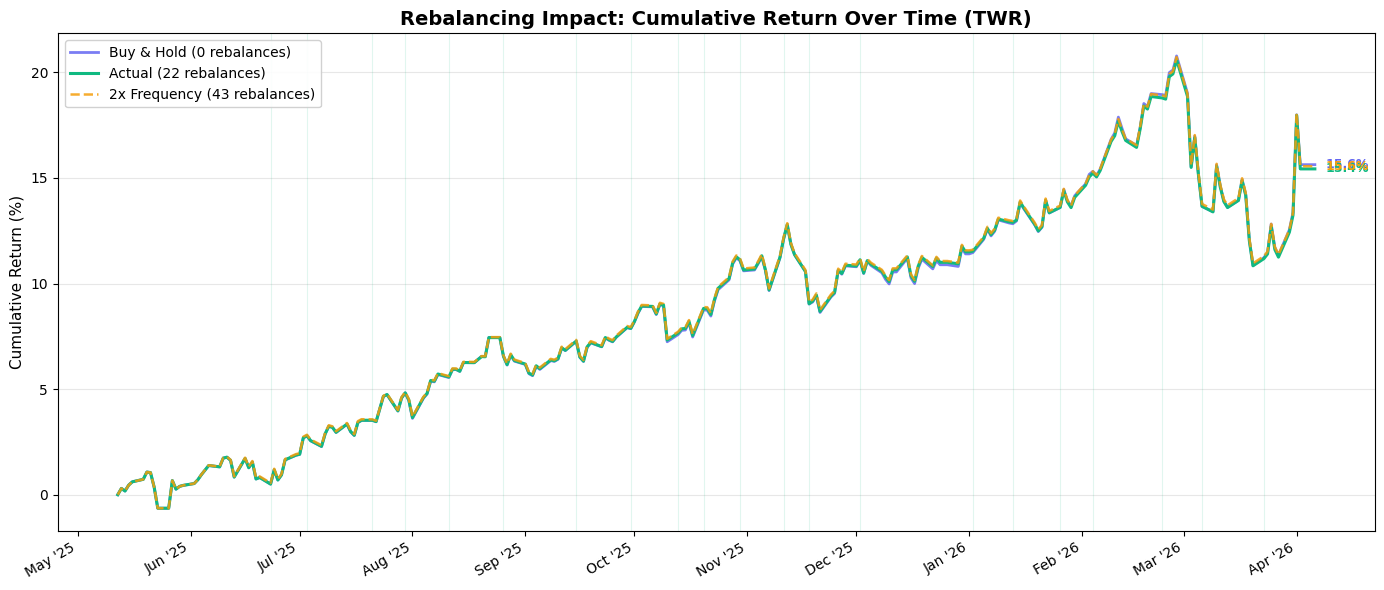


Final Cumulative Returns (TWR):
  Buy & Hold:              15.63%
  Actual (22 rebalances):  15.43%
  2x Frequency (43 rebal):  15.56%


In [6]:
# ---------- Rebalancing Impact Chart: B&H vs Actual vs 2x Rebalances ----------
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Actual (already computed)
# actual_twr_series is from the summary cell

# 2. Buy & Hold (calculated from fixed initial shares)
bnh_twr_series = bt.run_buy_and_hold_series(bnh_holdings)

# 3. 2x Frequency simulation
sorted_rebal = sorted(rebalance_dates)
double_rebal_dates = []
for i in range(len(sorted_rebal)):
    double_rebal_dates.append(sorted_rebal[i])
    if i < len(sorted_rebal) - 1:
        mid = sorted_rebal[i] + (sorted_rebal[i+1] - sorted_rebal[i]) / 2
        mid_bday = mid + pd.tseries.offsets.BDay(0)
        double_rebal_dates.append(mid_bday)
double_rebal_dates = sorted(set(double_rebal_dates))

# Define target weights for the simulation
target_weights = {tkr: cost/bnh_cost for tkr, cost in bnh_ticker_cost.items()}

double_twr_series = bt.run_simulated_rebalance(bnh_holdings, target_weights, double_rebal_dates)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(bt.all_dates, bnh_twr_series, label="Buy & Hold (0 rebalances)", 
        color="#6366f1", linewidth=2, alpha=0.85)
ax.plot(bt.all_dates, actual_twr_series, label=f"Actual ({len(sorted_rebal)} rebalances)", 
        color="#10b981", linewidth=2.2)
ax.plot(bt.all_dates, double_twr_series, label=f"2x Frequency ({len(double_rebal_dates)} rebalances)", 
        color="#f59e0b", linewidth=1.8, linestyle="--", alpha=0.85)

# Mark actual rebalance dates
for rd in sorted_rebal[1:]:
    ax.axvline(rd, color="#10b981", alpha=0.12, linewidth=0.8)

ax.set_title("Rebalancing Impact: Cumulative Return Over Time (TWR)", fontsize=14, fontweight="bold")
ax.set_ylabel("Cumulative Return (%)", fontsize=11)
ax.set_xlabel("")
ax.legend(loc="upper left", fontsize=10, framealpha=0.9)
ax.grid(axis="y", alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate(rotation=30)

# Annotate final values
for label, series, color in [
    ("B&H", bnh_twr_series, "#6366f1"),
    ("Actual", actual_twr_series, "#10b981"),
    ("2x", double_twr_series, "#f59e0b"),
]:
    final = series.iloc[-1]
    ax.annotate(f"{final:.1f}%", xy=(bt.all_dates[-1], final),
                xytext=(8, 0), textcoords="offset points",
                fontsize=9, fontweight="bold", color=color, va="center")

plt.tight_layout()
plt.show()

print(f"\nFinal Cumulative Returns (TWR):")
print(f"  Buy & Hold:              {bnh_twr_series.iloc[-1]:.2f}%")
print(f"  Actual ({len(sorted_rebal)} rebalances):  {actual_twr_series.iloc[-1]:.2f}%")
print(f"  2x Frequency ({len(double_rebal_dates)} rebal):  {double_twr_series.iloc[-1]:.2f}%")


### 1.4 Current Holdings (Share-Based)

Live snapshot of all held positions with current market value, cost basis,
and per-ticker money-weighted return.

In [7]:
holdings_rows = []
for t in sorted(share_ledger.keys()):
    shares = share_ledger[t]
    if shares <= 0: continue
    px = get_price_at(t, today) or 0
    val = round(shares * px, 2)
    cost = cost_basis[t]
    ticker_mwr = ((val / cost) - 1) * 100 if cost > 0 else 0
    holdings_rows.append({
        "Ticker": t,
        "Shares": round(shares, 4),
        "Price (£)": round(px, 2),
        "Value (£)": val,
        "Cost (£)": round(cost, 2),
        "P&L (£)": round(val - cost, 2),
        "MWR (%)": round(ticker_mwr, 2),
    })

holdings_df = pd.DataFrame(holdings_rows)
display(holdings_df)
print(f"Total Portfolio Value: £{holdings_df['Value (£)'].sum():,.2f}")
print(f"Total Cost Basis:     £{holdings_df['Cost (£)'].sum():,.2f}")
print(f"Total P&L:            £{holdings_df['P&L (£)'].sum():,.2f}")

,Ticker,Shares,Price (£),Value (£),Cost (£),P&L (£),MWR (%)
0,AUAD,176.1577,20.62,3632.81,3232.01,400.80,12.40
1,EMCP,3.3979,67.32,228.75,231.21,-2.46,-1.06
2,HMCH,78.7293,5.79,455.84,449.23,6.61,1.47
3,IBZL,81.4062,23.48,1911.82,1290.55,621.27,48.14
4,IGLT,22.9242,9.82,225.12,228.64,-3.52,-1.54
5,IMIB,175.9615,24.14,4248.59,3592.78,655.81,18.25
6,LCUK,144.6143,14.55,2104.14,1756.15,347.99,19.82
7,PRIJ,55.8769,29.02,1621.69,1332.76,288.93,21.68
8,PRIR,46.2379,14.70,679.88,673.30,6.58,0.98
9,QYLP,130.1067,12.29,1598.75,1552.99,45.76,2.95


Total Portfolio Value: £23,110.62
Total Cost Basis:     £20,760.29
Total P&L:            £2,350.33
